In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('D:/PyCharmProjects/GRES/data.csv')
df.head()

,Date,TurbinePowerSum,StationTempOutdoorAir,TurbineTempFeedSteamQ2,StationCoalHumidity,StationCoalAsh,StationConsumpNaturalFuel,Year,Season,DayOfWeek
0,2008-01-01 00:00:00,265.5747,-19.3035,220.71485,8.15,19.13,4134.1,2008,1,2
1,2008-01-01 01:00:00,263.3793,-19.0849,220.40270,NaN,NaN,NaN,2008,1,2
2,2008-01-01 02:00:00,265.3807,-19.3712,220.29765,NaN,NaN,NaN,2008,1,2
3,2008-01-01 03:00:00,263.3116,-18.8074,220.21890,NaN,NaN,NaN,2008,1,2
4,2008-01-01 04:00:00,252.4023,-18.9348,218.12160,NaN,NaN,NaN,2008,1,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70128 entries, 0 to 70127
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       70128 non-null  object 
 1   TurbinePowerSum            70100 non-null  float64
 2   StationTempOutdoorAir      70085 non-null  float64
 3   TurbineTempFeedSteamQ2     70100 non-null  float64
 4   StationCoalHumidity        2922 non-null   float64
 5   StationCoalAsh             2922 non-null   float64
 6   StationConsumpNaturalFuel  2922 non-null   float64
 7   Year                       70128 non-null  int64  
 8   Season                     70128 non-null  int64  
 9   DayOfWeek                  70128 non-null  int64  
dtypes: float64(6), int64(3), object(1)
memory usage: 5.4+ MB


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df = df.resample('D').mean()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2922 entries, 2008-01-01 to 2015-12-31
Freq: D
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TurbinePowerSum            2922 non-null   float64
 1   StationTempOutdoorAir      2922 non-null   float64
 2   TurbineTempFeedSteamQ2     2922 non-null   float64
 3   StationCoalHumidity        2922 non-null   float64
 4   StationCoalAsh             2922 non-null   float64
 5   StationConsumpNaturalFuel  2922 non-null   float64
 6   Year                       2922 non-null   float64
 7   Season                     2922 non-null   float64
 8   DayOfWeek                  2922 non-null   float64
dtypes: float64(9)
memory usage: 228.3 KB


## SARIMAX

In [5]:
target = 'TurbinePowerSum'

features = [
    'StationTempOutdoorAir',
    'TurbineTempFeedSteamQ2',
    'StationCoalHumidity',
    'StationCoalAsh',
    'StationConsumpNaturalFuel',
    'Year',
    'Season',
]

In [6]:
train_sm = df.loc[df.index < '2015-01-01']
test_sm = df.loc[df.index >= '2015-01-01']
X_train = train_sm[features]
X_test = test_sm[features]
y_train = train_sm[target]
y_test = test_sm[target]

In [7]:
"""import statsmodels.api as sm

sarimax_results = pd.DataFrame()

for p in range(3):
    for d in range(3):
        for q in range(3):
            mod = sm.tsa.statespace.SARIMAX(
                endog = y_train,
                exog = X_train,
                trend='c',
                order=(p,d,q),
                freq = 'D'
            )

            res = mod.fit(disp=False)
            model_results = pd.DataFrame(
                {
                    'p'   : p,
                    'd'   : d,
                    'q'   : q,
                    'AIC' : res.aic,
                    'BIC' : res.bic,
                    'HQIC': res.hqic,
                },
                index = [0]
            )
            sarimax_results = pd.concat([sarimax_results, model_results])"""

"import statsmodels.api as sm\n\nsarimax_results = pd.DataFrame()\n\nfor p in range(3):\n    for d in range(3):\n        for q in range(3):\n            mod = sm.tsa.statespace.SARIMAX(\n                endog = y_train,\n                exog = X_train,\n                trend='c',\n                order=(p,d,q),\n                freq = 'D'\n            )\n\n            res = mod.fit(disp=False)\n            model_results = pd.DataFrame(\n                {\n                    'p'   : p,\n                    'd'   : d,\n                    'q'   : q,\n                    'AIC' : res.aic,\n                    'BIC' : res.bic,\n                    'HQIC': res.hqic,\n                },\n                index = [0]\n            )\n            sarimax_results = pd.concat([sarimax_results, model_results])"

In [8]:
#sarimax_results

In [9]:
import statsmodels.api as sm

mod = sm.tsa.statespace.SARIMAX(
    endog = train_sm[target],
    exog = train_sm[features],
    trend='c',
    order=(0,0,0),
    freq = 'D'
)

res = mod.fit(disp=False)
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:        TurbinePowerSum   No. Observations:                 2557
Model:                        SARIMAX   Log Likelihood              -11750.858
Date:                Thu, 15 May 2025   AIC                          23519.716
Time:                        16:13:07   BIC                          23572.335
Sample:                    01-01-2008   HQIC                         23538.797
                         - 12-31-2014                                         
Covariance Type:                  opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
intercept                     0.0006    902.264   6.95e-07      1.000   -1768.404    1768.405
StationTempOutdoorAir         0.4047      0.053      7.672      0.000       0.301     

In [10]:
pred_sm = res.forecast(test_sm.shape[0], exog = test_sm[features])

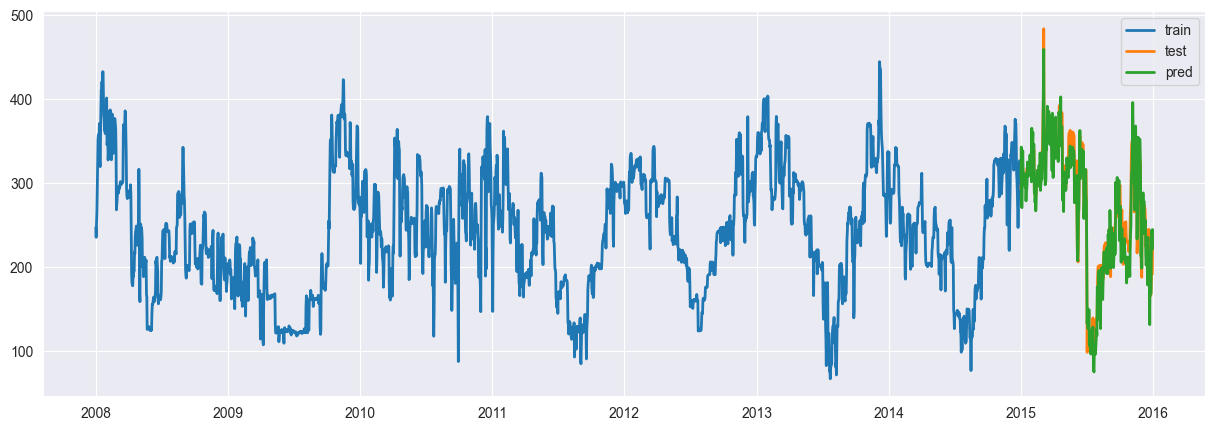

In [12]:
fig, ax = plt.subplots(figsize = (15,5))
ax.plot(train_sm[target], label='train', linewidth=2)
ax.plot(test_sm[target], label='test', linewidth=2)
ax.plot(pred_sm, label='pred', linewidth=2)
plt.legend()
plt.show()

In [12]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
print('R2 score:', r2_score(test_sm[target], pred_sm))
print('MAE score:', mean_absolute_error(test_sm[target], pred_sm))
print('MSE score:', mean_squared_error(test_sm[target], pred_sm))
print('RMSE score:', np.sqrt(mean_squared_error(test_sm[target], pred_sm)))
print('MAPE score:', mean_absolute_percentage_error(test_sm[target], pred_sm))

R2 score: 0.8981676378253187
MAE score: 18.081523121566462
MSE score: 494.19321571434386
RMSE score: 22.230456938946258
MAPE score: 0.07141510180540239


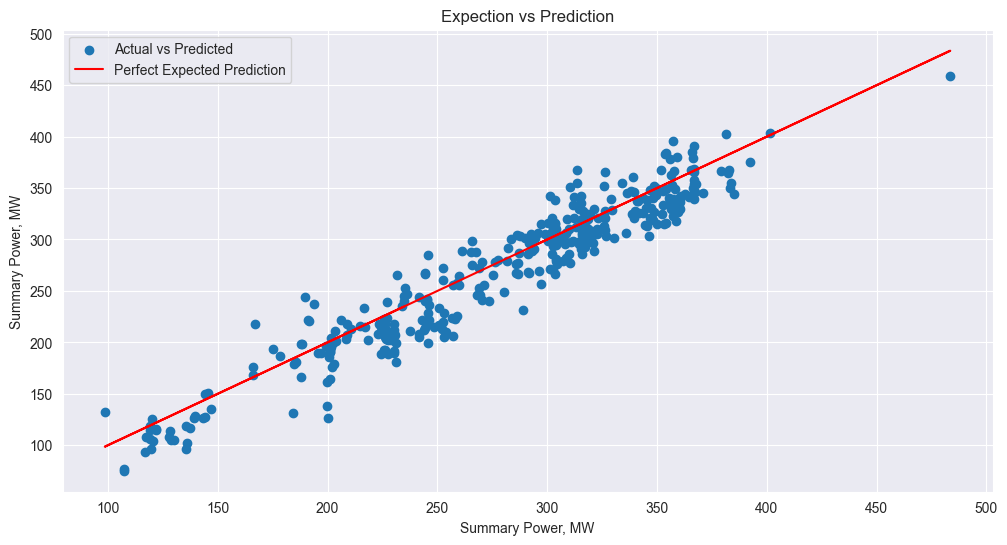

In [13]:
fig, ax = plt.subplots(figsize=(12,6),dpi=100);
plt.scatter(test_sm[target], pred_sm, label="Actual vs Predicted")
# Perfect predictions
plt.xlabel('Summary Power, MW')
plt.ylabel('Summary Power, MW')
plt.title('Expection vs Prediction')
plt.plot(test_sm[target], test_sm[target], 'r', label="Perfect Expected Prediction")
plt.legend()

## CatBoost

In [13]:
def add_time_features(data):
    data = data.copy()
    data['Month'] = data.index.month
    data['Day'] = data.index.day
    data['DayOfYear'] = data.index.dayofyear
    return data
df = add_time_features(df)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2922 entries, 2008-01-01 to 2015-12-31
Freq: D
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TurbinePowerSum            2922 non-null   float64
 1   StationTempOutdoorAir      2922 non-null   float64
 2   TurbineTempFeedSteamQ2     2922 non-null   float64
 3   StationCoalHumidity        2922 non-null   float64
 4   StationCoalAsh             2922 non-null   float64
 5   StationConsumpNaturalFuel  2922 non-null   float64
 6   Year                       2922 non-null   float64
 7   Season                     2922 non-null   float64
 8   DayOfWeek                  2922 non-null   float64
 9   Month                      2922 non-null   int32  
 10  Day                        2922 non-null   int32  
 11  DayOfYear                  2922 non-null   int32  
dtypes: float64(9), int32(3)
memory usage: 262.5 KB


In [15]:
df = df.sort_index()

In [16]:
cat_features = ['Year', 'Season', 'Month', 'DayOfYear', 'Day', 'DayOfWeek']
df[cat_features] = df[cat_features].astype('int')

In [17]:
target = 'TurbinePowerSum'

features = [
    'StationTempOutdoorAir',
    'TurbineTempFeedSteamQ2',
    'StationCoalHumidity',
    'StationCoalAsh',
    'StationConsumpNaturalFuel',
    'Year',
    'Season',
    'Month',
    'DayOfYear',
    'Day',
    'DayOfWeek'
]

In [18]:
train_cb = df.loc[df.index<'2015-01-01']
test_cb = df.loc[df.index>='2015-01-01']

X_train = train_cb[features]
y_train = train_cb[target]

X_test = test_cb[features]
y_test = test_cb[target]

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2922 entries, 2008-01-01 to 2015-12-31
Freq: D
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TurbinePowerSum            2922 non-null   float64
 1   StationTempOutdoorAir      2922 non-null   float64
 2   TurbineTempFeedSteamQ2     2922 non-null   float64
 3   StationCoalHumidity        2922 non-null   float64
 4   StationCoalAsh             2922 non-null   float64
 5   StationConsumpNaturalFuel  2922 non-null   float64
 6   Year                       2922 non-null   int32  
 7   Season                     2922 non-null   int32  
 8   DayOfWeek                  2922 non-null   int32  
 9   Month                      2922 non-null   int32  
 10  Day                        2922 non-null   int32  
 11  DayOfYear                  2922 non-null   int32  
dtypes: float64(6), int32(6)
memory usage: 228.3 KB


In [20]:
from catboost import CatBoostRegressor, Pool

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    early_stopping_rounds=50,
    task_type='CPU'
)

model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    cat_features=cat_features,
    verbose=100
)

0:	learn: 65.0585697	test: 74.0566464	best: 74.0566464 (0)	total: 166ms	remaining: 2m 46s
100:	learn: 15.7070167	test: 22.3896243	best: 22.3795512 (89)	total: 2.04s	remaining: 18.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 21.57543488
bestIteration = 147

Shrink model to first 148 iterations.


In [21]:
print(model.get_params())
print(model.get_feature_importance())

{'iterations': 1000, 'learning_rate': 0.1, 'depth': 6, 'loss_function': 'RMSE', 'random_seed': 42, 'task_type': 'CPU', 'early_stopping_rounds': 50}
[ 2.70148335 10.05603453  1.30424962  2.81064157 68.81214101  6.00951629
  2.90235337  4.39596489  0.09275188  0.6534815   0.26138198]


In [22]:
pred_cb = pd.Series(data = model.predict(data = X_test), index = X_test.index)

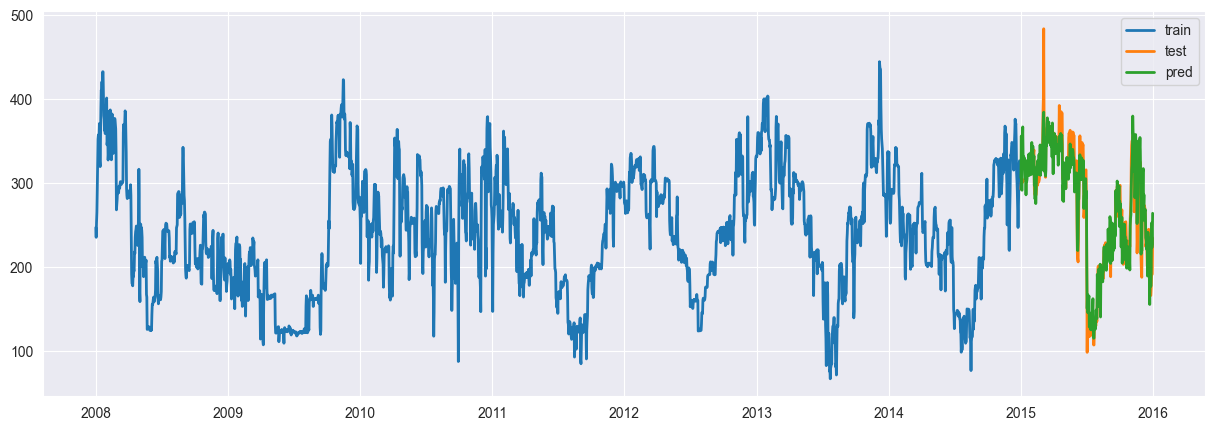

In [23]:
fig, ax = plt.subplots(figsize = (15,5))
ax.plot(y_train, label='train', linewidth=2)
ax.plot(y_test, label='test', linewidth=2)
ax.plot(pred_cb, label='pred', linewidth=2)
plt.legend()
plt.show()

In [24]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
print('R2 score:', r2_score(y_test, pred_cb))
print('MAE score:', mean_absolute_error(y_test, pred_cb))
print('MSE score:', mean_squared_error(y_test, pred_cb))
print('RMSE score:', np.sqrt(mean_squared_error(y_test, pred_cb)))
print('MAPE score:', mean_absolute_percentage_error(y_test, pred_cb))

R2 score: 0.9040802216230798
MAE score: 16.720156208536107
MSE score: 465.499402295936
RMSE score: 21.575435158900873
MAPE score: 0.06475132667508464


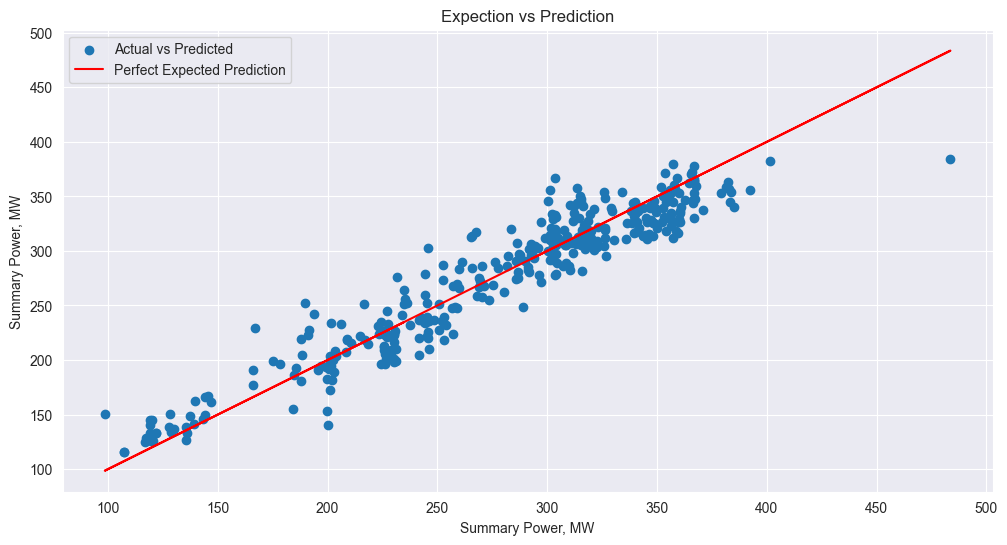

In [26]:
fig, ax = plt.subplots(figsize=(12,6),dpi=100);
plt.scatter(y_test, pred_cb, label="Actual vs Predicted")
# Perfect predictions
plt.xlabel('Summary Power, MW')
plt.ylabel('Summary Power, MW')
plt.title('Expection vs Prediction')
plt.plot(y_test,y_test,'r', label="Perfect Expected Prediction")
plt.legend()

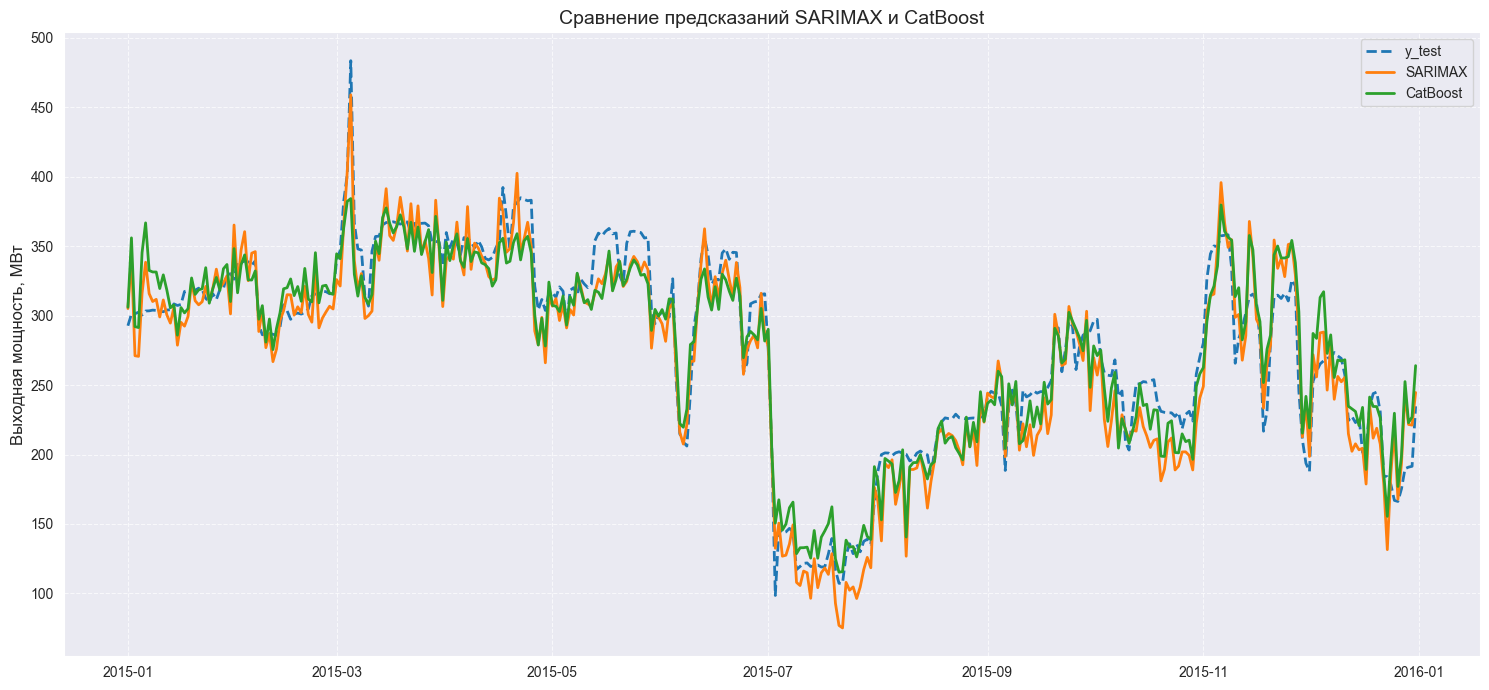

In [27]:
plt.figure(figsize=(15, 7))
plt.plot(y_test, label='y_test', linestyle='--', linewidth=2)
plt.plot(pred_sm, label='SARIMAX', linewidth=2)
plt.plot(pred_cb, label='CatBoost', linewidth=2)

plt.title('Сравнение предсказаний SARIMAX и CatBoost', fontsize=14)
plt.ylabel('Выходная мощность, МВт', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [28]:
from catboost import Pool

test_pool = Pool(
    X_test,
    label=y_test,
    cat_features=cat_features  # Explicitly declare categorical columns
)

metrics = model.eval_metrics(test_pool, metrics=['MAE'], plot=True)
mae = metrics['MAE'][-1]
mae

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

16.720154603613604

In [29]:
jupyter nbextension enable --py widgetsnbextension  # For Notebook

SyntaxError: invalid syntax (2095472513.py, line 1)